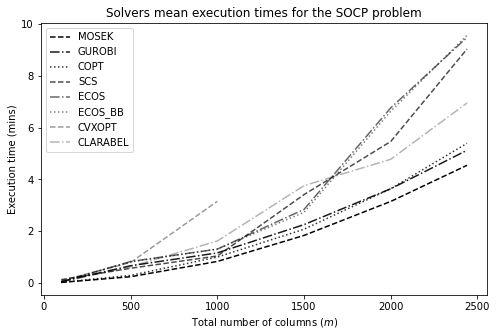

In [25]:
        
# Plot the time results in terms of the sample size
import matplotlib.pyplot as plt
import pandas as pd

df_final_results = pd.read_csv('results/benchmark/real-data-solver-benchmark-SOCP.csv')
df_final_results = df_final_results[df_final_results['error_quad'].notna()]

# plot 
line_styles = ['--', '-.', ':', '--', '-.', ':', '--', '-.', ':']
solvers = ['MOSEK', 'GUROBI', 'COPT' , 'SCS',   'ECOS', 'ECOS_BB',  'CVXOPT', 'CLARABEL']
fig, ax = plt.subplots(figsize=(8,5))
for i,solver in enumerate(solvers):
    # Mean of times for each sample size and solver
    df_final_results[df_final_results['solver']==solver].groupby('sample_size').mean().plot(y='time', style=line_styles[i] ,ax=ax, label=solver, alpha=(1-i*0.1), color='black')
    # All times for each sample size and solver
    # df_final_results[df_final_results['solver']==solver].plot(x='sample_size', y='time', ax=ax, label=solver)
ax.set_xlabel(r'Total number of columns ($m$)')
ax.set_ylabel('Execution time (mins)')
ax.set_title('Solvers mean execution times for the SOCP problem')
ax.legend()
plt.savefig('results/benchmark/plots/real-data-solver-benchmark.pdf', bbox_inches='tight', dpi=300)
plt.show()

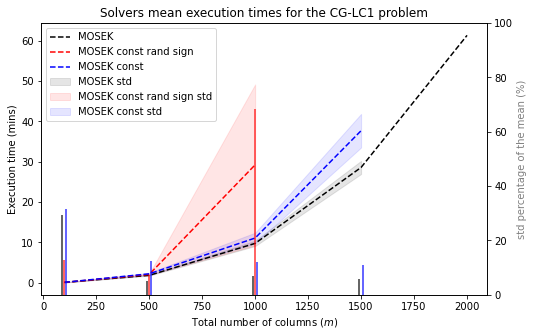

In [2]:
        
# Plot the time results in terms of the sample size
import matplotlib.pyplot as plt
import pandas as pd

df_final_results = pd.read_csv('results/benchmark/real-data-solver-benchmark-CG.csv')
df_final_results2 = pd.read_csv('results/benchmark/real-data-solver-benchmark-CG-const-rand.csv')
df_final_results3 = pd.read_csv('results/benchmark/real-data-solver-benchmark-CG-const.csv')
df_final_results = df_final_results[df_final_results['error_quad'].notna()]
df_final_results2 = df_final_results2[df_final_results2['error_quad'].notna()]
df_final_results3 = df_final_results3[df_final_results3['error_quad'].notna()]


# plot 
line_styles = ['--', '-.', ':', '--', '-.', ':', '--', '-.', ':']
solvers = ['MOSEK'] # , 'COPT' , 'SCS',   'ECOS', 'ECOS_BB',  'CVXOPT', 'CLARABEL' , 'GUROBI'
fig, ax = plt.subplots(figsize=(8,5))
for i,solver in enumerate(solvers):
    # Mean of times for each sample size and solver and confidence interval
    df_gb = df_final_results[df_final_results['solver']==solver].groupby('sample_size')
    df_gb_mean = df_gb.mean()
    df_gb_std = df_gb.std()
    df_gb2 = df_final_results2[df_final_results2['solver']==solver].groupby('sample_size')
    df_gb_mean2 = df_gb2.mean()
    df_gb_std2 = df_gb2.std()
    df_gb3 = df_final_results3[df_final_results3['solver']==solver].groupby('sample_size')
    df_gb_mean3 = df_gb3.mean()
    df_gb_std3 = df_gb3.std()
    df_gb_mean.plot(y='time', style=line_styles[i] ,ax=ax, label=solver, alpha=(1-i*0.1), color='black')
    df_gb_mean2.plot(y='time', style=line_styles[i] ,ax=ax, label=f'{solver} const rand sign', alpha=(1-i*0.1), color='red')
    df_gb_mean3.plot(y='time', style=line_styles[i] ,ax=ax, label=f'{solver} const', alpha=(1-i*0.1), color='blue')
    ax.fill_between(df_gb_mean.index, df_gb_mean['time']-df_gb_std['time'], df_gb_mean['time']+df_gb_std['time'], alpha=0.1, color='black', label='MOSEK std')
    ax.fill_between(df_gb_mean2.index, df_gb_mean2['time']-df_gb_std2['time'], df_gb_mean2['time']+df_gb_std2['time'], alpha=0.1, color='red', label=f'{solver} const rand sign std')
    ax.fill_between(df_gb_mean3.index, df_gb_mean3['time']-df_gb_std3['time'], df_gb_mean3['time']+df_gb_std3['time'], alpha=0.1, color='blue', label=f'{solver} const std')
    # Add a std percentage in terms of the mean, as barplot in the same figure as  the previous plot
    df_gb_std_perc = df_gb_std['time']/df_gb_mean['time']*100
    df_gb_std_perc2 = df_gb_std2['time']/df_gb_mean2['time']*100
    df_gb_std_perc3 = df_gb_std3['time']/df_gb_mean3['time']*100
    ax2 = ax.twinx()
    ax2.bar(df_gb_mean.index.to_numpy() - 10, df_gb_std_perc, alpha=0.6, color='black', width=10, label='std percentage of the mean')
    ax2.set_ylabel('std percentage of the mean (%)')
    ax2.set_ylim(0, 100)

    # same for the const rand sign, but move the bars to the right of the previous one
    ax2.bar(df_gb_mean2.index.to_numpy() - 2.5, df_gb_std_perc2, alpha=0.6, color='red', width=10, label='std percentage of the mean')#, align='edge')
    ax2.set_ylabel('std percentage of the mean (%)', color='gray')
    ax2.set_ylim(0, 100)

    # same for the const, but move the barplot to the left of the previous one
    ax2.bar(df_gb_mean3.index.to_numpy() + 2.5, df_gb_std_perc3, alpha=0.6, color='blue', width=10, label='std percentage of the mean', align='edge')
    ax2.set_ylabel('std percentage of the mean (%)', color='gray')
    ax2.set_ylim(0, 100)

    # ax2.grid(False)

    # All times for each sample size and solver
    


ax.set_xlabel(r'Total number of columns ($m$)')
ax.set_ylabel('Execution time (mins)')
ax.set_title('Solvers mean execution times for the CG-LC1 problem')
ax.legend()
# ax.set_xlim(0, 1200)
# ax.set_ylim(0, 50)
# plt.savefig('results/benchmark/plots/real-data-solver-benchmark.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [3]:
# df_final_results.loc[(df_final_results['solver']==solver) & (df_final_results['sample_size']>100),:]

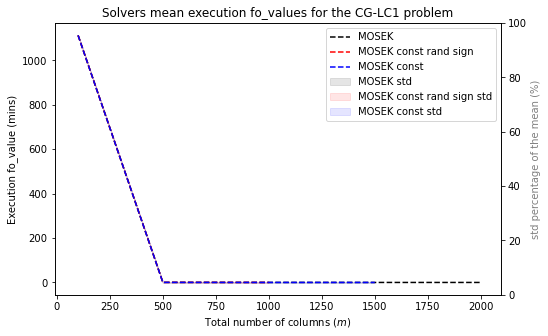

In [4]:
        
# Plot the fo_value results in terms of the sample size
import matplotlib.pyplot as plt
import pandas as pd

df_final_results = pd.read_csv('results/benchmark/real-data-solver-benchmark-CG.csv')
df_final_results2 = pd.read_csv('results/benchmark/real-data-solver-benchmark-CG-const-rand.csv')
df_final_results3 = pd.read_csv('results/benchmark/real-data-solver-benchmark-CG-const.csv')
df_final_results = df_final_results[df_final_results['error_quad'].notna()]
df_final_results2 = df_final_results2[df_final_results2['error_quad'].notna()]
df_final_results3 = df_final_results3[df_final_results3['error_quad'].notna()]

# # Filter sample_size > 100
# df_final_results = df_final_results.loc[df_final_results['sample_size']>100,:]
# df_final_results2 = df_final_results2.loc[df_final_results2['sample_size']>100,:]
# df_final_results3 = df_final_results3.loc[df_final_results3['sample_size']>100,:]

# plot 
line_styles = ['--', '-.', ':', '--', '-.', ':', '--', '-.', ':']
solvers = ['MOSEK'] # , 'COPT' , 'SCS',   'ECOS', 'ECOS_BB',  'CVXOPT', 'CLARABEL' , 'GUROBI'
fig, ax = plt.subplots(figsize=(8,5))
for i,solver in enumerate(solvers):
    # Mean of fo_values for each sample size and solver and confidence interval
    df_gb = df_final_results[df_final_results['solver']==solver].groupby('sample_size')
    df_gb_mean = df_gb.mean()
    df_gb_std = df_gb.std()
    df_gb2 = df_final_results2[df_final_results2['solver']==solver].groupby('sample_size')
    df_gb_mean2 = df_gb2.mean()
    df_gb_std2 = df_gb2.std()
    df_gb3 = df_final_results3[df_final_results3['solver']==solver].groupby('sample_size')
    df_gb_mean3 = df_gb3.mean()
    df_gb_std3 = df_gb3.std()
    df_gb_mean.plot(y='fo_value', style=line_styles[i] ,ax=ax, label=solver, alpha=(1-i*0.1), color='black')
    df_gb_mean2.plot(y='fo_value', style=line_styles[i] ,ax=ax, label=f'{solver} const rand sign', alpha=(1-i*0.1), color='red')
    df_gb_mean3.plot(y='fo_value', style=line_styles[i] ,ax=ax, label=f'{solver} const', alpha=(1-i*0.1), color='blue')
    ax.fill_between(df_gb_mean.index, df_gb_mean['fo_value']-df_gb_std['fo_value'], df_gb_mean['fo_value']+df_gb_std['fo_value'], alpha=0.1, color='black', label='MOSEK std')
    ax.fill_between(df_gb_mean2.index, df_gb_mean2['fo_value']-df_gb_std2['fo_value'], df_gb_mean2['fo_value']+df_gb_std2['fo_value'], alpha=0.1, color='red', label=f'{solver} const rand sign std')
    ax.fill_between(df_gb_mean3.index, df_gb_mean3['fo_value']-df_gb_std3['fo_value'], df_gb_mean3['fo_value']+df_gb_std3['fo_value'], alpha=0.1, color='blue', label=f'{solver} const std')
    # Add a std percentage in terms of the mean, as barplot in the same figure as  the previous plot
    df_gb_std_perc = df_gb_std['fo_value']/df_gb_mean['fo_value']*100
    df_gb_std_perc2 = df_gb_std2['fo_value']/df_gb_mean2['fo_value']*100
    df_gb_std_perc3 = df_gb_std3['fo_value']/df_gb_mean3['fo_value']*100
    ax2 = ax.twinx()
    ax2.bar(df_gb_mean.index.to_numpy() - 10, df_gb_std_perc, alpha=0.6, color='black', width=10, label='std percentage of the mean')
    ax2.set_ylabel('std percentage of the mean (%)')
    ax2.set_ylim(0, 100)

    # same for the const rand sign, but move the bars to the right of the previous one
    ax2.bar(df_gb_mean2.index.to_numpy() + 2.5, df_gb_std_perc2, alpha=0.6, color='red', width=10, label='std percentage of the mean', align='edge')
    ax2.set_ylabel('std percentage of the mean (%)', color='gray')
    ax2.set_ylim(0, 100)

    # same for the const, but move the barplot to the left of the previous one
    ax2.bar(df_gb_mean3.index.to_numpy() - 2.5, df_gb_std_perc3, alpha=0.6, color='blue', width=10, label='std percentage of the mean') #, align='edge')
    ax2.set_ylabel('std percentage of the mean (%)', color='gray')
    ax2.set_ylim(0, 100)

    # ax2.grid(False)

    # All fo_values for each sample size and solver
    


ax.set_xlabel(r'Total number of columns ($m$)')
ax.set_ylabel('Execution fo_value (mins)')
ax.set_title('Solvers mean execution fo_values for the CG-LC1 problem')
ax.legend()
# ax.set_xlim(0, 1200)
# ax.set_ylim(0, 50)
# plt.savefig('results/benchmark/plots/real-data-solver-benchmark.pdf', bbox_inches='tight', dpi=300)
plt.show()# 

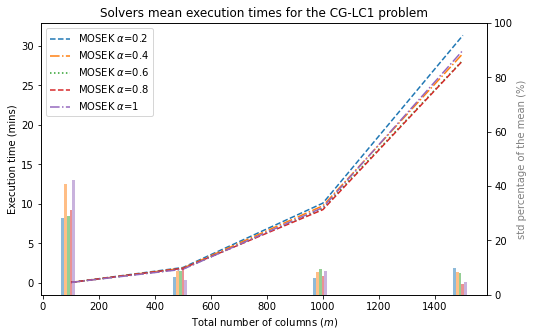

In [5]:
        
# Plot the time results in terms of the sample size
import matplotlib.pyplot as plt
import pandas as pd

df_final_results = pd.read_csv('results/benchmark/real-data-solver-benchmark-alpha.csv')
# plot 
line_styles = ['--', '-.', ':', '--', '-.', ':', '--', '-.', ':']
solvers = ['MOSEK'] # , 'COPT' , 'SCS',   'ECOS', 'ECOS_BB',  'CVXOPT', 'CLARABEL' , 'GUROBI'
fig, ax = plt.subplots(figsize=(8,5))
for i,solver in enumerate(solvers):
    alphas = [0.2, 0.4, 0.6, 0.8, 1]
    for j,alpha in enumerate(alphas):
        # Mean of times for each sample size and solver and confidence interval
        df_gb = df_final_results[(df_final_results['solver']==solver) & (df_final_results['alpha']==alpha)].groupby('sample_size')
        # df_gb = df_final_results[df_final_results['solver']==solver].groupby('sample_size')
        df_gb_mean = df_gb.mean()
        df_gb_std = df_gb.std()
        df_gb_mean.plot(y='time', style=line_styles[j] ,ax=ax, label=fr'{solver} $\alpha$={alpha}', alpha=1, color=f'C{j}')
        # if alpha == .4:
        #     ax.fill_between(df_gb_mean.index, df_gb_mean['time']-df_gb_std['time'], df_gb_mean['time']+df_gb_std['time'], alpha=0.1, color=f'C{j}') # , label=fr'{solver} $\alpha$={alpha}'
        

        # Add a std percentage in terms of the mean, as barplot in the same figure as  the previous plot
        df_gb_std_perc = df_gb_std['time']/df_gb_mean['time']*100
        if alpha == alphas[0]:
            ax2 = ax.twinx()
        ax2.bar(df_gb_mean.index.to_numpy()-(30-10*j), df_gb_std_perc, alpha=0.5, color=f'C{j}', width=10, label='std percentage of the mean')
        if alpha == alphas[0]:
            ax2.set_ylabel('std percentage of the mean (%)', color='gray')
            ax2.set_ylim(0, 100)

        


ax.set_xlabel(r'Total number of columns ($m$)')
ax.set_ylabel('Execution time (mins)')
ax.set_title('Solvers mean execution times for the CG-LC1 problem')
ax.legend()
# ax.set_xlim(0, 450)
# ax.set_ylim(0, 2)
plt.savefig('results/benchmark/plots/alpha-benchmark-aphas1.pdf', bbox_inches='tight', dpi=300)
plt.show()   #tau * suma(z) * alpha

KeyboardInterrupt: 

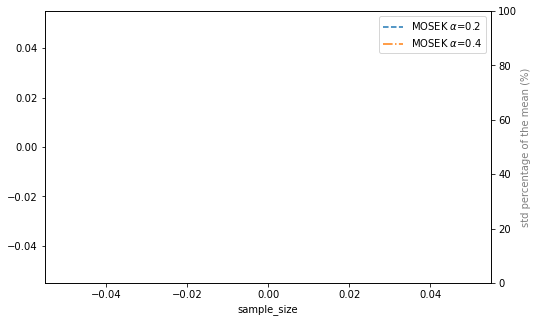

In [6]:
        
# Plot the fo_value results in terms of the sample size
import matplotlib.pyplot as plt
import pandas as pd

df_final_results = pd.read_csv('results/benchmark/real-data-solver-benchmark.csv')
# plot 
line_styles = ['--', '-.', ':', '--', '-.', ':', '--', '-.', ':']
solvers = ['MOSEK'] # , 'COPT' , 'SCS',   'ECOS', 'ECOS_BB',  'CVXOPT', 'CLARABEL' , 'GUROBI'
fig, ax = plt.subplots(figsize=(8,5))
for i,solver in enumerate(solvers):
    alphas = [0.2, 0.4, 0.6, 0.8, 1]
    for j,alpha in enumerate(alphas):
        # Mean of fo_values for each sample size and solver and confidence interval
        df_gb = df_final_results[(df_final_results['solver']==solver) & (df_final_results['alpha']==alpha)].groupby('sample_size')
        # df_gb = df_final_results[df_final_results['solver']==solver].groupby('sample_size')
        df_gb_mean = df_gb.mean()
        df_gb_std = df_gb.std()
        df_gb_mean.plot(y='fo_value', style=line_styles[j] ,ax=ax, label=fr'{solver} $\alpha$={alpha}', alpha=1, color=f'C{j}')
        if alpha == .2:
            ax.fill_between(df_gb_mean.index, df_gb_mean['fo_value']-df_gb_std['fo_value'], df_gb_mean['fo_value']+df_gb_std['fo_value'], alpha=0.1, color=f'C{j}') # , label=fr'{solver} $\alpha$={alpha}'
        

        # Add a std percentage in terms of the mean, as barplot in the same figure as  the previous plot
        df_gb_std_perc = df_gb_std['fo_value']/df_gb_mean['fo_value']*100000000
        if alpha == alphas[0]:
            ax2 = ax.twinx()
        ax2.bar(df_gb_mean.index.to_numpy()-(30-10*j), df_gb_std_perc, alpha=0.5, color=f'C{j}', width=10, label='std percentage of the mean')
        if alpha == alphas[0]:
            ax2.set_ylabel('std percentage of the mean (%)', color='gray')
            ax2.set_ylim(0, 100)

        


ax.set_xlabel(r'Total number of columns ($m$)')
ax.set_ylabel('Execution fo_value (mins)')
ax.set_title('Solvers mean execution fo_values for the CG-LC1 problem')
ax.legend()
# ax.set_xlim(1000, 1600)
# ax.set_ylim(0, .08)
# plt.savefig('results/benchmark/plots/real-data-solver-benchmark.pdf', bbox_inches='tight', dpi=300)
plt.show()

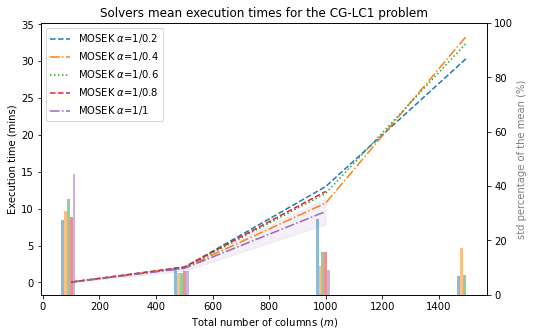

In [ ]:
        
# Plot the time results in terms of the sample size
import matplotlib.pyplot as plt
import pandas as pd

df_final_results = pd.read_csv('results/benchmark/real-data-solver-benchmark.csv')
# plot 
line_styles = ['--', '-.', ':', '--', '-.', ':', '--', '-.', ':']
solvers = ['MOSEK'] # , 'COPT' , 'SCS',   'ECOS', 'ECOS_BB',  'CVXOPT', 'CLARABEL' , 'GUROBI'
fig, ax = plt.subplots(figsize=(8,5))
for i,solver in enumerate(solvers):
    alphas_ = [0.2, 0.4, 0.6, 0.8, 1]
    for j,alpha_ in enumerate(alphas):
        alpha = 1/alpha_
        # print(alpha, j)
        # Mean of times for each sample size and solver and confidence interval
        df_gb = df_final_results[(df_final_results['solver']==solver) & (df_final_results['alpha']==alpha)].groupby('sample_size')
        # df_gb = df_final_results[df_final_results['solver']==solver].groupby('sample_size')
        df_gb_mean = df_gb.mean()
        df_gb_std = df_gb.std()
        df_gb_mean.plot(y='time', style=line_styles[j] ,ax=ax, label=fr'{solver} $\alpha$=1/{alpha_}', alpha=1, color=f'C{j}')
        if alpha_ == 1:
            ax.fill_between(df_gb_mean.index, df_gb_mean['time']-2*df_gb_std['time'], df_gb_mean['time']+2*df_gb_std['time'], alpha=0.1, color=f'C{j}') # , label=fr'{solver} $\alpha$={alpha}'
        

        # Add a std percentage in terms of the mean, as barplot in the same figure as  the previous plot
        df_gb_std_perc = df_gb_std['time']/df_gb_mean['time']*100
        if alpha_ == alphas_[0]:
            ax2 = ax.twinx()
        ax2.bar(df_gb_mean.index.to_numpy()-(30-10*j), df_gb_std_perc, alpha=0.5, color=f'C{j}', width=10, label='std percentage of the mean')
        if alpha_ == alphas_[0]:
            ax2.set_ylabel('std percentage of the mean (%)', color='gray')
            ax2.set_ylim(0, 100)

        


ax.set_xlabel(r'Total number of columns ($m$)')
ax.set_ylabel('Execution time (mins)')
ax.set_title('Solvers mean execution times for the CG-LC1 problem')
ax.legend()
# ax.set_xlim(0, 450)
# ax.set_ylim(0, 2)
# plt.savefig('results/benchmark/plots/alpha-benchmark-alphas2.pdf', bbox_inches='tight', dpi=300)
plt.show()  

---
## Reunión 21-02-2024

#### 1. Plots para ver qué solver es más rápido para resolver la versión relajada de Lasso: $\min_{\beta} \frac{1}{2}||y-X\beta||_2^2 + \lambda||\beta||_1$.

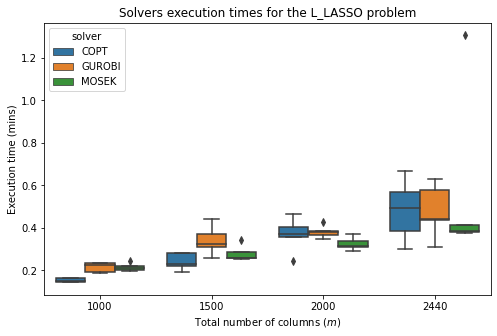

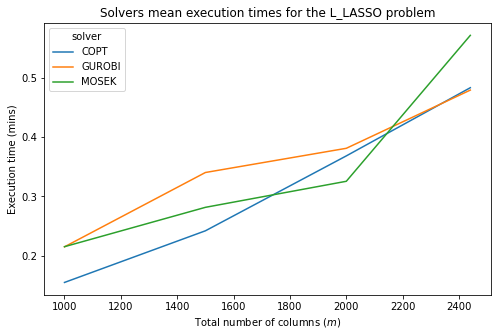

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# Read data from results/elastic-net/socp_CG_comparison_LASSO.csv
df_final_results = pd.read_csv('./results/elastic-net/socp_CG_comparison_LASSO_solver_L_LASSO.csv').sort_values(by='solver')

# Boxplot of the values, with sample_size on x axis, time on y axis, and solver as the hue
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(x='sample_size', y='time', hue='solver', data=df_final_results, ax=ax)
ax.set_xlabel(r'Total number of columns ($m$)')
ax.set_ylabel('Execution time (mins)')
ax.set_title('Solvers execution times for the L_LASSO problem')
# plt.savefig('results/elastic-net/plots/socp_CG_comparison_LASSO.pdf', bbox_inches='tight', dpi=300)
plt.show()


# Same plot, but with a lineplot of means instead of a boxplot
df_mean = df_final_results.groupby(['sample_size', 'solver']).mean().reset_index()
fig, ax = plt.subplots(figsize=(8,5))
sns.lineplot(x='sample_size', y='time', hue='solver', data=df_mean, ax=ax)
ax.set_xlabel(r'Total number of columns ($m$)')
ax.set_ylabel('Execution time (mins)')
ax.set_title('Solvers mean execution times for the L_LASSO problem')
# plt.savefig('results/elastic-net/plots/socp_CG_comparison_LASSO.pdf', bbox_inches='tight', dpi=300)
plt.show()

#### 2. Plot para ver las comparaciones entre distintos modelos para resolver Lasso. 


Conclusions:
- The scikit implementation is the slowest. I thinks it is used only because of the max_iter parameter, which may be implemented in our CG algorithm.
- The best implementation is the one with the CG algorithm directly on the LASSO error cone.

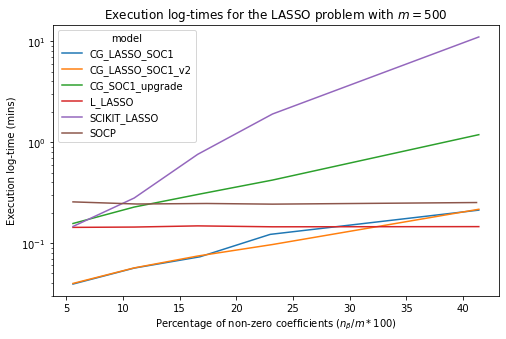

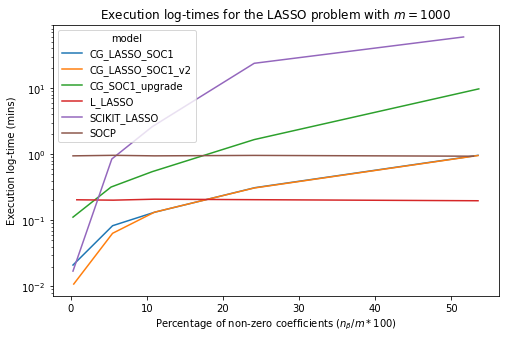

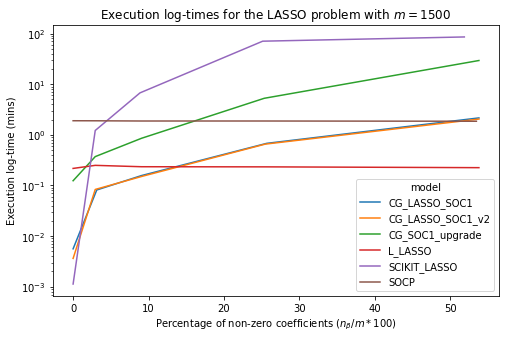

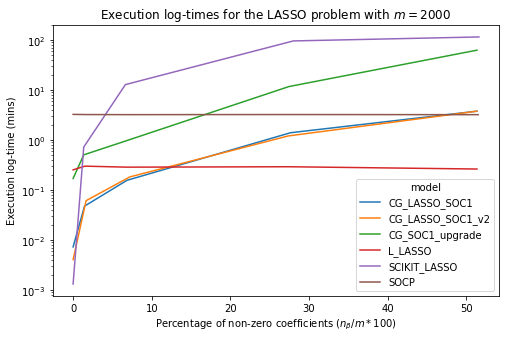

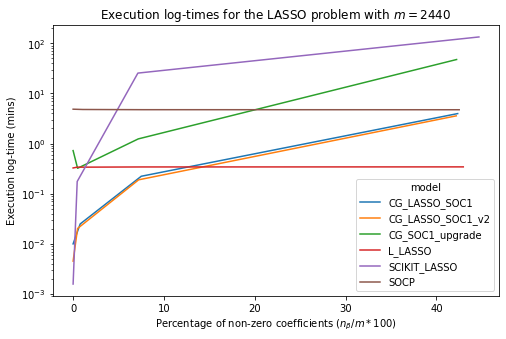

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Read data from results/elastic-net/socp_CG_comparison_LASSO.csv
df_final_results = pd.read_csv('./results/elastic-net/socp_CG_comparison_LASSO_6models.csv').sort_values(by=['sample_size','model','n_betas'])

# different linestyles for each model
line_styles = ['-', '--', '-.', ':', '--', '-.', ':', '--', '-.', ':']

# Different plots by sample_size, each one of them is a lineplot of the time by model, with x axis being the n_betas and y axis the time. The hue is the model
sample_sizes = df_final_results['sample_size'].unique()
for i,sample_size in enumerate(sample_sizes):
    df_sample_size = df_final_results[df_final_results['sample_size']==sample_size]
    # fig, ax = plt.subplots(figsize=(8,5))
    # sns.lineplot(x='n_betas', y='time', hue='model', data=df_sample_size, ax=ax, markers=True, dashes=line_styles[i])
    # ax.set_xlabel(r'Number of non-zero coefficients ($n_{\beta}$)')
    # ax.set_ylabel('Execution time (mins)')
    # ax.set_title(fr'Execution times for the LASSO problem with $m=${sample_size}')
    # ax.set_xlim(0, 100)
    # # ax.set_ylim(0, 6)
    # # plt.savefig(f'results/elastic-net/plots/socp_CG_comparison_LASSO_sample_size_{sample_size}.pdf', bbox_inches='tight', dpi=300)
    # plt.show()

    # # Same plot, but with a log scale of times
    # fig, ax = plt.subplots(figsize=(8,5))
    # sns.lineplot(x='n_betas', y='time', hue='model', data=df_sample_size, ax=ax, markers=True) # , dashes=line_styles[i]  style='model',
    # ax.set_xlabel(r'Number of non-zero coefficients ($n_{\beta}$)')
    # ax.set_ylabel('Log. execution time (mins)')
    # ax.set_title(f'Log. execution times for the LASSO problem with sample size {sample_size}')
    # ax.set_yscale('log')
    # ax.set_xlim(0, 200)
    # # plt.savefig(f'results/elastic-net/plots/socp_CG_comparison_LASSO_sample_size_{sample_size}_log.pdf', bbox_inches='tight', dpi=300)
    # plt.show()

    # Same plot, but with a log scale of times and x-axis is the percentage n_beras/sample_size*100
    df_sample_size['n_betas_percentage'] = df_sample_size['n_betas']/df_sample_size['sample_size']*100
    fig, ax = plt.subplots(figsize=(8,5))
    sns.lineplot(x='n_betas_percentage', y='time', hue='model', data=df_sample_size, ax=ax, markers=True, dashes=line_styles[i])
    ax.set_xlabel(r'Percentage of non-zero coefficients ($n_{\beta}/m*100$)')
    ax.set_ylabel('Execution log-time (mins)')
    ax.set_title(f'Execution log-times for the LASSO problem with $m=${sample_size}')
    ax.set_yscale('log')
    # ax.set_xlim(0, 20)
    # plt.savefig(f'results/elastic-net/plots/socp_CG_comparison_LASSO_sample_size_{sample_size}_percentage_log.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    




#### 3. Plot para ver si el cambio de $\tau$ y $\kappa$ afecta el tiempo de ejecución del algoritmo CG_SOC1_upgrade

- Hay error numérico si $\alpha$ = 1e-6 
- No parece haber 

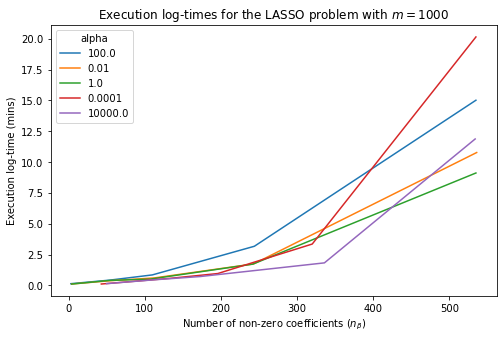

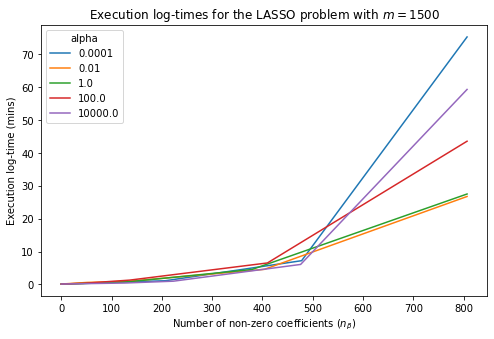

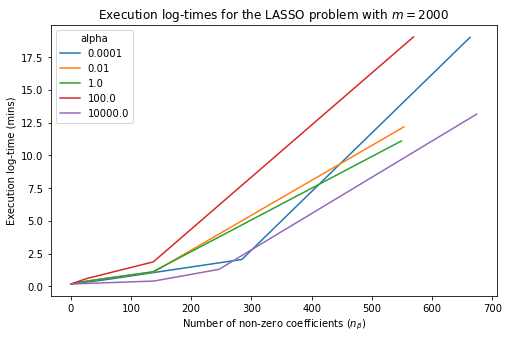

In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# # ignore warnings
# import warnings
# warnings.filterwarnings('ignore')

# Read data from results/elastic-net/socp_CG_comparison_LASSO.csv
df_final_results = pd.read_csv('./results/elastic-net/socp_CG_comparison_LASSO_alphas.csv').sort_values(by=['sample_size','model','n_betas'])

# different linestyles for each model
line_styles = ['-', '--', '-.', ':', '--', '-.', ':', '--', '-.', ':']

# Different plots by sample_size, each one of them is a lineplot of the time by model, with x axis being the n_betas and y axis the time. The hue is the model
sample_sizes = df_final_results['sample_size'].unique()
for i,sample_size in enumerate(sample_sizes):
    df_sample_size = df_final_results[df_final_results['sample_size']==sample_size]
    df_sample_size['alpha'] = df_sample_size['alpha'].astype(str)
    # fig, ax = plt.subplots(figsize=(8,5))
    # # sns.violinplot(x='alpha', y='time', data=df_sample_size, ax=ax)
    # sns.boxplot(x='alpha', y='time', data=df_sample_size, ax=ax)
    # ax.set_xlabel(r'Alpha coefficient (${\alpha}$)')
    # ax.set_ylabel('Execution time (mins)')
    # ax.set_title(fr'Execution times for the CG_SOC1_upgrade model with $m=${sample_size}')
    # # ax.set_xlim(0, 100)
    # # ax.set_ylim(0, 6)
    # # plt.savefig(f'results/elastic-net/plots/socp_CG_comparison_LASSO_sample_size_{sample_size}.pdf', bbox_inches='tight', dpi=300)
    # plt.show()

    # lineplot
    fig, ax = plt.subplots(figsize=(8,5))
    sns.lineplot(x='n_betas', y='time', hue='alpha', data=df_sample_size, ax=ax)
    ax.set_xlabel(r'Number of non-zero coefficients ($n_{\beta}$)')
    ax.set_ylabel('Execution log-time (mins)')
    ax.set_title(f'Execution log-times for the LASSO problem with $m=${sample_size}')
    # ax.set_xscale('log')
    # ax.set_xlim(0, 20)
    # plt.savefig(f'results/elastic-net/plots/socp_CG_comparison_LASSO_sample_size_{sample_size}_percentage_log.pdf', bbox_inches='tight', dpi=300)
    plt.show()
